In [1]:
# Loading Connectome 
import sys
sys.path.append("../../src")
from data_loader import loader
root="../"
adj = loader('c_elegans', root=root)

In [2]:
import numpy as np 
from connalysis.network import topology
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# M is a matrix with the entries the number of synapses.  That is
# If M is the connectome, it can be obtained by doing
# adj = M.matrix
adj.data

array([ 2,  1, 16, ...,  2,  1,  4], shape=(2186,))

In [4]:
out={}
out["max"] = topology.edge_participation(adj, max_simplices=True, return_simplex_counts=True)
out["all"] = topology.edge_participation(adj, max_simplices=False, return_simplex_counts=True)

edge_par, skeleta, weights = {}, {}, {}
for key in out.keys():
    edge_par[key] = out[key][0]

[2026-05-26 18:17:56,615] INFO: Done running flagser
[2026-05-26 18:17:56,620] INFO: Done running flagser


In [5]:
# This can take a bit of time in large matrices 
for key in out.keys():
    skeleta[key] = topology.extract_submatrices_from_edge_participation(edge_par[key],adj.shape[0], thresh=1)
    weights[key] = {dim: adj.multiply(skeleta[key][f"dimension_{dim}"]).data for dim in edge_par[key].columns}



In [6]:
# Adding weight to the edge participation data frame, for the plot on the second row
adj_csr = adj.tocsr()  
rows, cols = np.array(edge_par[key].index.tolist()).T

for key in edge_par.keys():
    edge_par[key]["weight"] = np.asarray(adj_csr[rows, cols]).ravel()




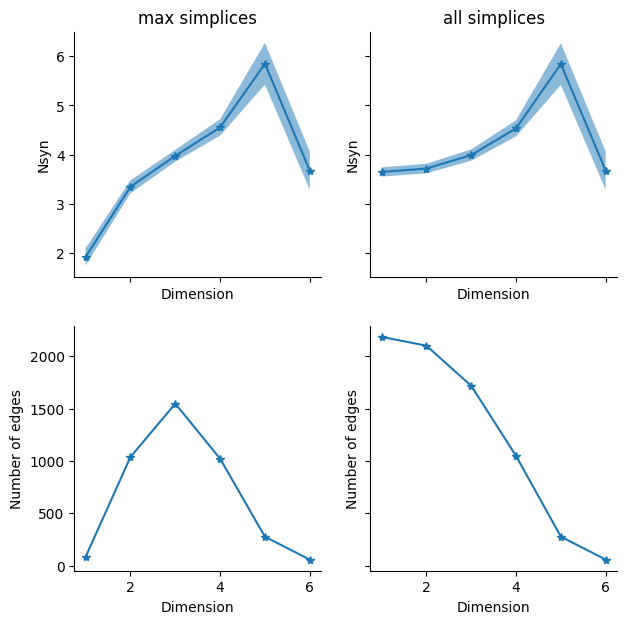

In [7]:
fig,axs = plt.subplots(2,2, figsize = (7,7),sharey="row", sharex="col")

for j, key in enumerate(weights.keys()):
    i=0 # Edge weights across simplices
    df = pd.DataFrame.from_dict(weights[key], orient="index")
    axs[i,j].plot(df.index, df.mean(axis=1), marker = "*")
    axs[i,j].fill_between(df.index, df.mean(axis=1)+df.sem(axis=1), df.mean(axis=1)-df.sem(axis=1), alpha=0.5)
    axs[i,j].set_xlabel("Dimension")
    axs[i,j].set_ylabel("Nsyn")
    axs[i,j].spines[["top", "right"]].set_visible(False)
    axs[i,j].set_title(f"{key} simplices")

    i=1 # Edge counts across dimensions
    axs[i,j].plot((~df.isna()).sum(axis=1).drop(0),marker = "*")
    axs[i,j].set_xlabel("Dimension")
    axs[i,j].set_ylabel("Number of edges")
    axs[i,j].spines[["top", "right"]].set_visible(False)
